In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [3]:
import mlxtend
import pandas as pd 
import numpy as np
import seaborn as sns 
from matplotlib import pyplot
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
from sqlalchemy import create_engine


In [4]:
engine = create_engine(
    "mssql+pyodbc://@DESKTOP-4D0BAHG/master"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

pd.read_sql("SELECT 1 AS test", engine)


,test
0,1


In [5]:
pd.read_sql(
    "SELECT TOP 1000 * FROM dbo.online_retail_II",
    engine
)

query = """
SELECT
    Invoice,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    Price,
    Country,
    Quantity * Price AS TotalPrice,
    [Customer ID]
FROM dbo.online_retail_II
WHERE Invoice NOT LIKE 'C%'
  AND Price > 0
  AND Quantity > 0
  AND Description IS NOT NULL
  AND [Customer ID] IS NOT NULL
  AND LTRIM(RTRIM([Customer ID])) <> ''
"""




In [7]:
chunks = pd.read_sql(query, engine, chunksize=20000)

dfs = []
for i, chunk in enumerate(chunks, 1):
    print(f"{i}. parça alındı → {len(chunk)} satır")
    dfs.append(chunk)

df = pd.concat(dfs, ignore_index=True)


1. parça alındı → 20000 satır
2. parça alındı → 20000 satır
3. parça alındı → 20000 satır
4. parça alındı → 20000 satır
5. parça alındı → 20000 satır
6. parça alındı → 20000 satır
7. parça alındı → 20000 satır
8. parça alındı → 20000 satır
9. parça alındı → 20000 satır
10. parça alındı → 20000 satır
11. parça alındı → 20000 satır
12. parça alındı → 20000 satır
13. parça alındı → 20000 satır
14. parça alındı → 20000 satır
15. parça alındı → 20000 satır
16. parça alındı → 20000 satır
17. parça alındı → 20000 satır
18. parça alındı → 20000 satır
19. parça alındı → 20000 satır
20. parça alındı → 20000 satır
21. parça alındı → 20000 satır
22. parça alındı → 20000 satır
23. parça alındı → 20000 satır
24. parça alındı → 20000 satır
25. parça alındı → 20000 satır
26. parça alındı → 20000 satır
27. parça alındı → 20000 satır
28. parça alındı → 20000 satır
29. parça alındı → 20000 satır
30. parça alındı → 20000 satır
31. parça alındı → 20000 satır
32. parça alındı → 20000 satır
33. parça alındı 

In [ ]:
df.shape

(805531, 9)

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,805531.0,13.290797,1.0,2.0,5.0,12.0,80995.0,143.635681
InvoiceDate,805531,2011-01-02 10:29:42.696308480,2009-12-01 07:45:00,2010-07-07 12:08:00,2010-12-03 15:10:00,2011-07-28 13:05:00,2011-12-09 12:50:00,NaN
Price,805531.0,3.206633,0.03,1.25,1.95,3.75,10953.5,29.199495
TotalPrice,805531.0,22.026997,0.06,4.95,11.85,19.5,168469.6,224.044407


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805531 entries, 0 to 805530
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805531 non-null  object        
 1   StockCode    805531 non-null  object        
 2   Description  805531 non-null  object        
 3   Quantity     805531 non-null  int64         
 4   InvoiceDate  805531 non-null  datetime64[ns]
 5   Price        805531 non-null  float64       
 6   Country      805531 non-null  object        
 7   TotalPrice   805531 non-null  float64       
 8   Customer ID  805531 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 55.3+ MB


In [ ]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Country        0
TotalPrice     0
Customer ID    0
dtype: int64

## “Satın Alma Davranışına Dayalı Ürün Öneri Modeli”



In [8]:
transactions= df.groupby("Invoice")["StockCode"].apply(list)
te=TransactionEncoder()
X= te.fit(transactions).transform(transactions,sparse=True)
freq=fpgrowth(pd.DataFrame.sparse.from_spmatrix(X,columns=te.columns_),min_support=0.01,use_colnames=True)
kurallar=association_rules(freq,metric="lift",min_threshold=1)
kurallar=kurallar[["antecedents","consequents","support","confidence","lift"]].sort_values("lift",ascending=False)

C:\Users\casper\AppData\Local\Temp\ipykernel_17112\4140045371.py:4: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  freq=fpgrowth(pd.DataFrame.sparse.from_spmatrix(X,columns=te.columns_),min_support=0.01,use_colnames=True)


In [9]:
oneri_tbl = (kurallar.query("antecedents.str.len()==1 and consequents.str.len()==1")
                      .assign(Urun_Kodu = lambda x :x["antecedents"].str.join(""),
                              Oneri = lambda x: x["consequents"].str.join(""),
                              Birlikte_Satis_Adedi = lambda x: (x["support"] * len(transactions)).astype(int))
                  
            
            .sort_values(["Urun_Kodu","lift","Birlikte_Satis_Adedi"], ascending=[True,False,False])
            .groupby("Urun_Kodu",group_keys=False)
            .head(3)
            .loc[:, ["Urun_Kodu", "Oneri", "lift", "confidence", "Birlikte_Satis_Adedi"]]
            .reset_index(drop=True)
)

## CLTV ANALIZI (BG/NBD & GAMMA-GAMMA)


In [10]:
import datetime as dt
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

c:\Users\casper\AppData\Local\Programs\Python\Python312\Lib\site-packages\autograd\numpy\numpy_wrapper.py:7: DeprecationWarning: numpy.core.einsumfunc is deprecated and has been renamed to numpy._core.einsumfunc. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.einsumfunc._parse_einsum_input.
  from numpy.core.einsumfunc import _parse_einsum_input
c:\Users\casper\AppData\Local\Programs\Python\Python312\Lib\site-packages\autograd\scipy\misc.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc as osp_misc


In [11]:
analysis_date = df["InvoiceDate"].max() + dt.timedelta(days=1)
cltv_df = summary_data_from_transaction_data(df,"Customer ID","InvoiceDate",monetary_value_col="TotalPrice",observation_period_end= analysis_date)
cltv_df = cltv_df[cltv_df["monetary_value"] > 0]


In [12]:
# BG/NBD Modeli (Satın Alma Sayısı Tahmini)
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(cltv_df["frequency"],cltv_df["recency"],cltv_df["T"])
cltv_df["exp_sales_6_month"]=bgf.predict(8*3 ,cltv_df["frequency"],cltv_df["recency"],cltv_df["T"])


In [13]:
# Gamma-Gamma Modeli (Ortalama Kârlılık Tahmini)
ggf=GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(cltv_df["frequency"],cltv_df["monetary_value"])
cltv_df["exp_avg_profit"] = ggf.conditional_expected_average_profit(cltv_df["frequency"],cltv_df["monetary_value"])

In [14]:
# CLTV TAHMINI (6 AYLIK) VE SEGMENTLERE AYIRMA
cltv_df["cltv_value"]=ggf.customer_lifetime_value(bgf,cltv_df["frequency"],cltv_df["recency"],cltv_df["T"],cltv_df["monetary_value"],time=6,freq="W", discount_rate= 0.01)
cltv_df["Segment"] = pd.qcut(cltv_df["cltv_value"],4,labels=["D","C","B","A"])
print(cltv_df.sort_values(by="cltv_value", ascending=False).head())

             frequency  recency      T  monetary_value  exp_sales_6_month  exp_avg_profit    cltv_value Segment
Customer ID                                                                                                    
16446.0            1.0    205.0  206.0   168469.600000           0.176506   204353.469086  37828.158790       A
18102.0           66.0    738.0  739.0     9189.930455           1.917328     9214.499470  18534.912877       A
14646.0           90.0    736.0  738.0     5809.905333           2.602593     5821.302898  15894.579134       A
17450.0           30.0    430.0  439.0     6924.523000           1.383399     6965.411744  10108.597382       A
14156.0          120.0    729.0  739.0     2607.329750           3.444402     2611.181005   9435.690078       A


## CHURN TAHMINI



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

In [16]:
churn_threshold = 90
churn_df = cltv_df.copy()

In [17]:
churn_df["days_since_last_purchase"] = churn_df["T"] - churn_df["recency"]
churn_df["is_churned"] = churn_df["days_since_last_purchase"].apply(lambda x : 1 if x > 90 else 0 )
X = churn_df[["recency","frequency","monetary_value","T"]]
y = churn_df["is_churned"]


In [18]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
rf_model = RandomForestClassifier(random_state=42,n_estimators=100)
rf_model.fit(X_scaled,y)
churn_df["churn_prob"] = rf_model.predict_proba(X_scaled)[:,1]
print(churn_df[["is_churned","churn_prob"]].head())

             is_churned  churn_prob
Customer ID                        
12346.0               1        0.99
12347.0               0        0.00
12348.0               0        0.01
12349.0               0        0.00
12352.0               0        0.02


In [ ]:
importance_df = pd.DataFrame({
    'Degisken': X.columns,
    'Etki_Puani': rf_model.feature_importances_
}).sort_values(by='Etki_Puani', ascending=False)
print(importance_df)

         Degisken  Etki_Puani
3               T    0.488164
0         recency    0.403066
1       frequency    0.072196
2  monetary_value    0.036574


In [ ]:
churn_df.isnull().sum()

frequency                   0
recency                     0
T                           0
monetary_value              0
exp_sales_6_month           0
exp_avg_profit              0
cltv_value                  0
Segment                     0
days_since_last_purchase    0
is_churned                  0
churn_prob                  0
dtype: int64

## ZAMAN SERISI



In [19]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


01:43:47 - cmdstanpy - INFO - Chain [1] start processing
01:43:49 - cmdstanpy - INFO - Chain [1] done processing


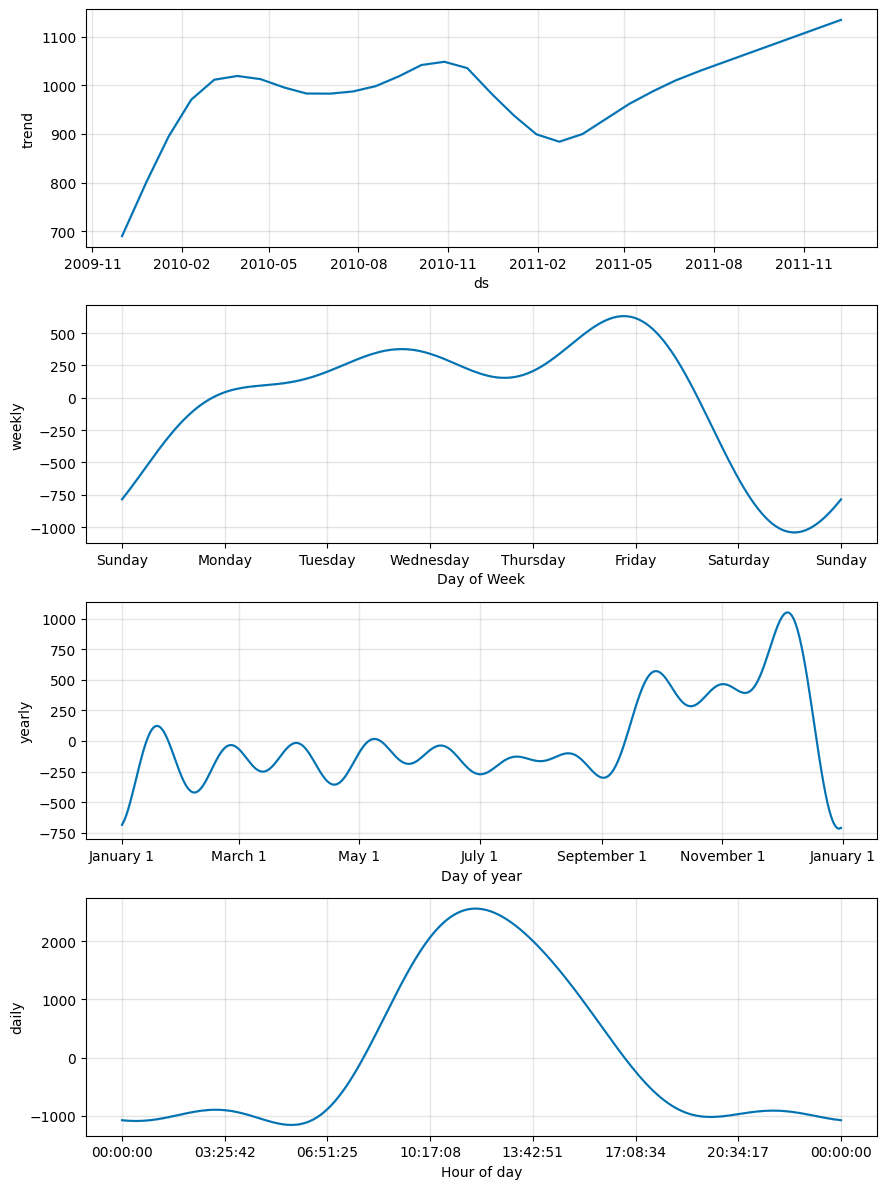

In [20]:
hourly_sales = df.set_index("InvoiceDate").resample("H")["TotalPrice"].sum().reset_index()
hourly_sales.columns=["ds","y"]
model = Prophet(yearly_seasonality=True , weekly_seasonality=True, daily_seasonality=True)
model.fit(hourly_sales)
forecast_hist = model.predict(hourly_sales)
fig = model.plot_components(forecast_hist)


In [23]:
from prophet import Prophet
from sklearn.metrics import r2_score
weekly_sales = hourly_sales.set_index('ds').resample('W')['y'].sum().reset_index()
model_weekly = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,interval_width=0.95)
model_weekly.fit(weekly_sales)
forecast_test = model_weekly.predict(weekly_sales)
y_gercek = weekly_sales['y']
y_tahmin = forecast_test['yhat']

from sklearn.metrics import r2_score
r2_weekly = r2_score(y_gercek, y_tahmin)

print(f" Haftalık Skor (Yeni)   : {r2_weekly:.2f}")
print(weekly_sales[weekly_sales['ds'] == '2010-01-03'])

03:18:37 - cmdstanpy - INFO - Chain [1] start processing
03:18:38 - cmdstanpy - INFO - Chain [1] done processing


 Haftalık Skor (Yeni)   : 0.77
          ds    y
4 2010-01-03  0.0


In [25]:
future_weekly = model_weekly.make_future_dataframe(periods=26, freq='W')
forecast_weekly = model_weekly.predict(future_weekly)
export_weekly = forecast_weekly[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
export_weekly['yhat_lower'] = forecast_weekly['yhat_lower'].clip(lower=0)
export_weekly.columns = ['Date', 'Predicted_Sales', 'Lower_Bound', 'Upper_Bound']
export_weekly.to_sql('Tbl_Py_Satis_Tahmin_Haftalik', engine, if_exists='replace', index=False)

132

In [ ]:
oneri_tbl.to_sql(
    name="Fact_ProductReco",
    con=engine,
    schema="dbo",
    if_exists="replace",
    index=False
)



317

In [ ]:
cltv_df.reset_index().to_sql(
    "Dim_Customer_CLTV",
    engine,
    schema="dbo",
    if_exists="replace",
    index=False
)


228

In [ ]:
churn_df.reset_index().to_sql(
    "Fact_Churn",
    engine,
    schema="dbo",
    if_exists="replace",
    index=False
)


13